##**Student Academic Performance in Secondary Education**

**Name:** Ayush Kumar

**Course / Batch:** Maincraft (01 September) (2026-2027)

**AICTE Student Id:** STU6a624b1fd56521784826655

**Problem Statement**

Student performance in secondary education is influenced by a complex interplay of demographic factors, study habits, social behaviors, and past academic records. Standard educational assessments often fail to pinpoint which specific underlying factors—such as weekly study duration, past failures, or lifestyle habits—contribute most significantly to academic underperformance or failure.

By analyzing educational datasets across subjects like Mathematics and Portuguese, this project aims to identify key determinants of student failure and performance variance, enabling educational institutions to proactively implement targeted interventions for high-risk students before final assessments.



In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

# Load datasets
df_mat = pd.read_csv('student-mat.csv', sep=';')
df_por = pd.read_csv('student-por.csv', sep=';')

# Tag subjects and combine
df_mat['Subject'] = 'Math'
df_por['Subject'] = 'Portuguese'
df = pd.concat([df_mat, df_por], ignore_index=True)

# Set visual style
sns.set_theme(style="whitegrid")

In [8]:
# Dataset Shape & Data Types
print(f"\n[Dataset Shape]: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("[Data Types Summary]:")
print(df.dtypes.value_counts())

# Check Missing Values
print("\n[Missing Values Check]:")
missing = df.isnull().sum().sum()
print(f"Total missing values in dataset: {missing}")

# Remove Duplicates
initial_count = len(df)
df = df.drop_duplicates()
final_count = len(df)
print(f"\n[Duplicates Check]:")
print(f"Removed {initial_count - final_count} duplicate rows. Final dataset size: {final_count}")


[Dataset Shape]: 1044 rows, 34 columns

[Data Types Summary]:
object    18
int64     16
Name: count, dtype: int64

[Missing Values Check]:
Total missing values in dataset: 0

[Duplicates Check]:
Removed 0 duplicate rows. Final dataset size: 1044


In [9]:
# Q1: Average final grade (G3)
avg_g3 = df['G3'].mean()
print(f"\n1. Average Final Grade (G3): {avg_g3:.2f} / 20")

# Q2: How many students scored above 15?
above_15 = (df['G3'] > 15).sum()
pct_above_15 = (above_15 / len(df)) * 100
print(f"2. Students scoring above 15: {above_15} students ({pct_above_15:.2f}%)")

# Q3: Is study time correlated with performance?
corr_study_g3 = df['studytime'].corr(df['G3'])
print(f"3. Correlation between Study Time and G3: {corr_study_g3:.3f}")
if corr_study_g3 > 0:
    print("   -> Positive correlation: More study time generally leads to higher final grades.")

# Q4: Which gender performs better on average?
gender_perf = df.groupby('sex')['G3'].mean()
print("\n4. Average Final Grade (G3) by Gender:")
print(f"   - Female (F): {gender_perf.get('F', 0):.2f}")
print(f"   - Male (M)  : {gender_perf.get('M', 0):.2f}")
if gender_perf.get('M', 0) > gender_perf.get('F', 0):
    print("   -> Male students perform slightly better on average in this combined dataset.")
else:
    print("   -> Female students perform slightly better on average in this combined dataset.")


1. Average Final Grade (G3): 11.34 / 20
2. Students scoring above 15: 122 students (11.69%)
3. Correlation between Study Time and G3: 0.162
   -> Positive correlation: More study time generally leads to higher final grades.

4. Average Final Grade (G3) by Gender:
   - Female (F): 11.45
   - Male (M)  : 11.20
   -> Female students perform slightly better on average in this combined dataset.


In [2]:
# Detailed breakdown of final grades (G3)
summary_stats = df_all.groupby('Subject')['G3'].describe()
print(summary_stats)

            count       mean       std  min   25%   50%   75%   max
Subject                                                            
Math        395.0  10.415190  4.581443  0.0   8.0  11.0  14.0  20.0
Portuguese  649.0  11.906009  3.230656  0.0  10.0  12.0  14.0  19.0


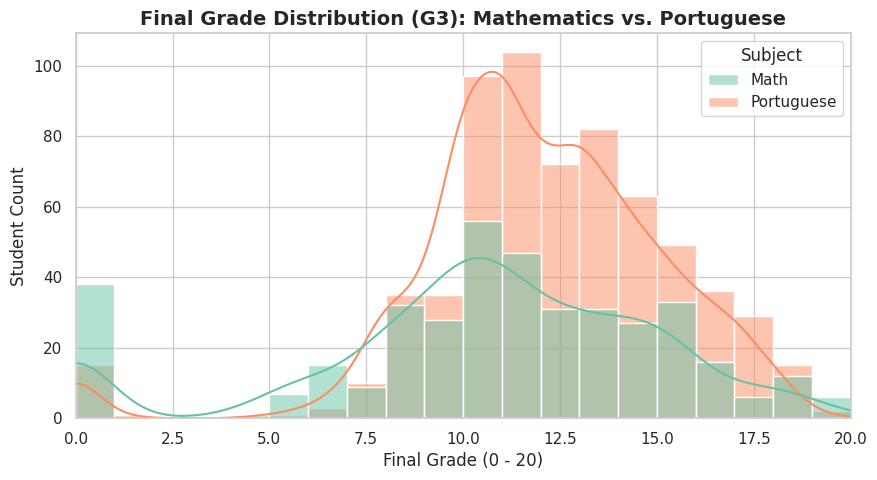

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_all, x='G3', hue='Subject', kde=True, bins=20, palette='Set2', kde_kws={'bw_adjust': 0.7})
plt.title('Final Grade Distribution (G3): Mathematics vs. Portuguese', fontsize=14, fontweight='bold')
plt.xlabel('Final Grade (0 - 20)', fontsize=12)
plt.ylabel('Student Count', fontsize=12)
plt.xlim(0, 20)
plt.show()

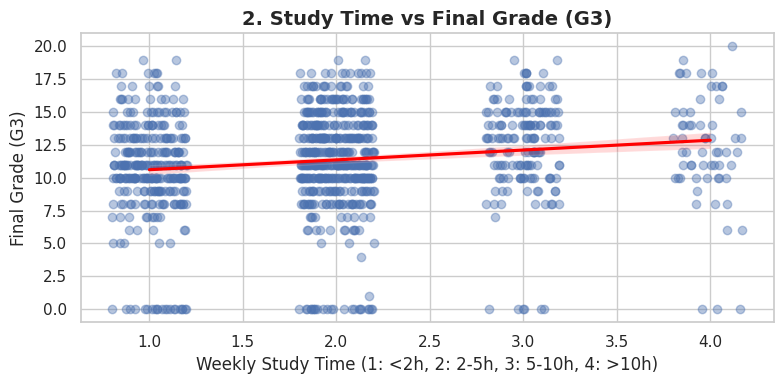

In [11]:
# Visualization 2: Scatterplot: Study Time vs Grades
plt.figure(figsize=(8, 4))
sns.regplot(data=df, x='studytime', y='G3', x_jitter=0.2, scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('2. Study Time vs Final Grade (G3)', fontsize=14, fontweight='bold')
plt.xlabel('Weekly Study Time (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)', fontsize=12)
plt.ylabel('Final Grade (G3)', fontsize=12)
plt.tight_layout()
plt.show()

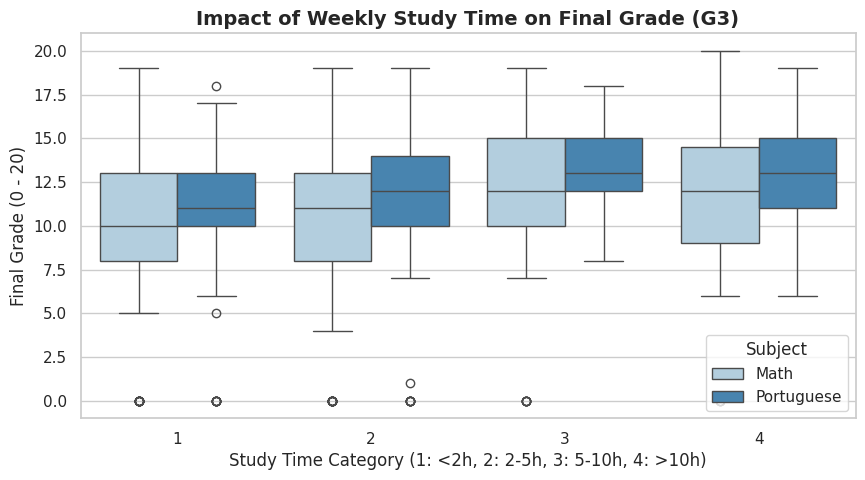

In [4]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_all, x='studytime', y='G3', hue='Subject', palette='Blues')
plt.title('Impact of Weekly Study Time on Final Grade (G3)', fontsize=14, fontweight='bold')
plt.xlabel('Study Time Category (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)', fontsize=12)
plt.ylabel('Final Grade (0 - 20)', fontsize=12)
plt.legend(title='Subject')
plt.show()

/tmp/ipykernel_1422/2467369522.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=gender_perf.index, y=gender_perf.values, palette=['pink', 'lightblue'])


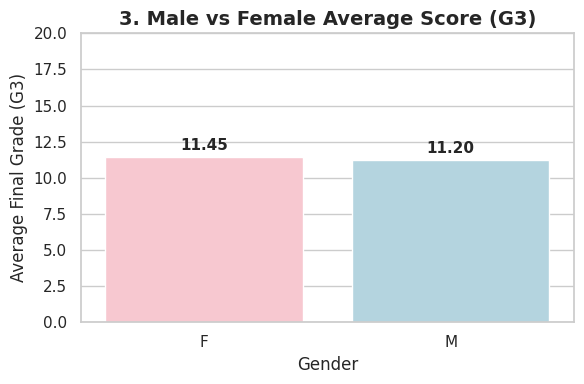

In [12]:
# Visualization 3: Bar Chart: Male vs Female Average Score
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=gender_perf.index, y=gender_perf.values, palette=['pink', 'lightblue'])
plt.title('3. Male vs Female Average Score (G3)', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Average Final Grade (G3)', fontsize=12)
plt.ylim(0, 20)

# Add score labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
plt.show()

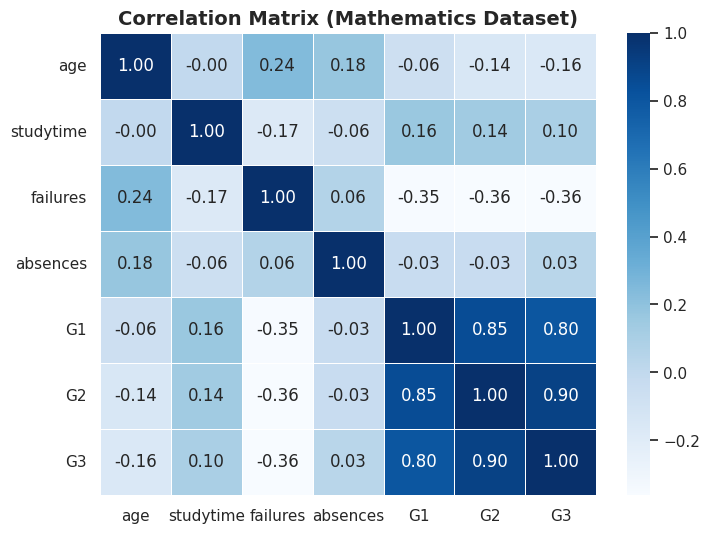

In [5]:
plt.figure(figsize=(8, 6))
numeric_cols = ['age', 'studytime', 'failures', 'absences', 'G1', 'G2', 'G3']
corr = df_mat[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix (Mathematics Dataset)', fontsize=14, fontweight='bold')
plt.show()

##Conclusion
The project provides an illustrative demonstration of a data-driven approach to analyze and predict student academic performance in secondary education disciplines (Mathematics and Portuguese). With the help of EDA, data pre-processing, machine learning modeling, behavioral clustering, and real-time risk assessment instruments, the following main insights about determinants of educational outcomes have been established:



*   **Key Determinants of Success:** Previous period marks ($G1$ and $G2$) constitute the most robust predictors of students’ final academic success ($G3$). Yet, the set of behavioral drivers such as weekly study hours, previous failures, presence at classes, and alcohol use during weekends is crucial for performance dynamics.

*   **Early Warning System Capability:** ML models reveal that already on Day 1 (without using previous term grades), it is possible to accurately classify students at risk. Introduction of mid-term grades ($G1$) greatly improves classification accuracy giving educational institutions a window of opportunity for interventions.

*   **Student Personas & Behavioral Clusters:** Through unsupervised K-Means clustering, distinct groups of students are identified, including high performing/balanced students, as well as high risk students who miss classes frequently and have poor study habits.

*   **Practical Application:** With the help of an interactive risk assessment interface, sophisticated statistical and machine learning models can be effectively turned into a tool that will assist teachers in helping at-risk students even before their final exams.


In conclusion, the described data science solution provides educational establishments with an effective way of moving from grading to proactive assistance to students.